In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle

plt.style.use(['science','notebook'])
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

## Transferability results

In [4]:
n_coords = 150
k = 10 # 30 / 3, to keep same ratio k/N
n_best = 5

variables_train = {}
imbalances_train = {}
imbalances_val1 = {}
imbalances_val2 = {}
for i_fold in range(3):
        variables_train[i_fold], imbalances_train[i_fold], imbalances_val1[i_fold], imbalances_val2[i_fold] = (
            pickle.load(open(f"./pickles_transferability/nbest{n_best}_ncoords{n_coords}_k{k}_fold{i_fold}.p","rb")) 
        )

In [2]:
from itertools import combinations
# initializing list
test_list = [1, 7, 4, 3]
 
# printing original list 
print("The original list : " + str(test_list))

# All possible pairs in List
# Using combinations()
res = list(combinations(test_list, 2))
res

The original list : [1, 7, 4, 3]


[(1, 7), (1, 4), (1, 3), (7, 4), (7, 3), (4, 3)]

In [3]:
25 * 25

625

### Imbalance vs n_features for train and validation sets

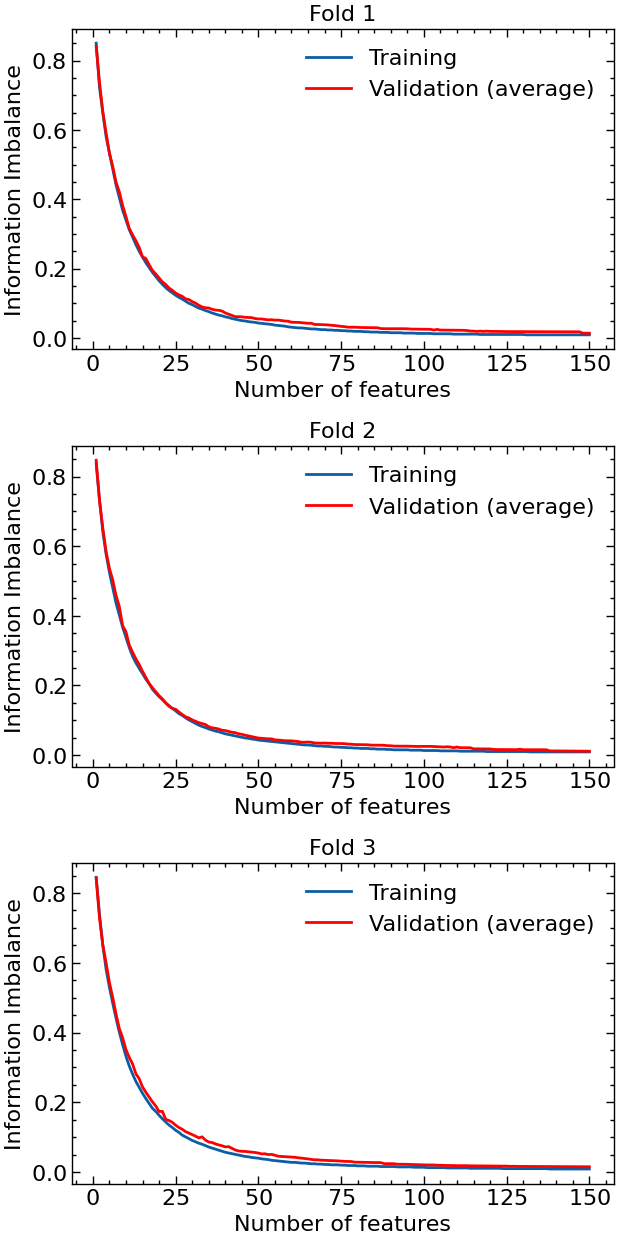

In [12]:
fig, ax = plt.subplots(3,1,figsize=(7,15),gridspec_kw={"hspace": 0.3})

for i_fold in range(3):
    ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_train[i_fold][:,1], '-', label="Training")
    #ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_val1[i_fold][1,:], '-', label="Validation 1")
    #ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_val2[i_fold][1,:], '-', label="Validation 2")
    ax[i_fold].plot(np.arange(1,n_coords+1), 0.5*(imbalances_val1[i_fold][1,:]+imbalances_val2[i_fold][1,:]), '-', color="red", label="Validation (average)")
    ax[i_fold].set(xlabel="Number of features", ylabel="Information Imbalance", title=f"Fold {i_fold+1}")
    ax[i_fold].legend()
plt.savefig("./figures/transferability_imbalances.pdf", dpi=300)
plt.show()


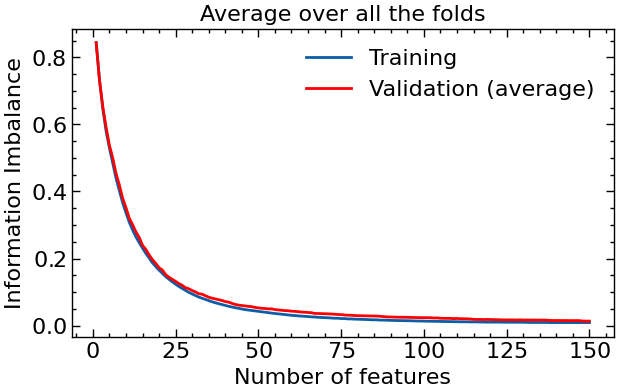

In [9]:
fig, ax = plt.subplots(1,1,figsize=(7,4),gridspec_kw={"hspace": 0.3})

ax.plot(np.arange(1,n_coords+1), (imbalances_train[0][:,1]+imbalances_train[1][:,1]+imbalances_train[2][:,1])/3, '-', label="Training")
ax.plot(np.arange(1,n_coords+1), 0.5*(imbalances_val1[0][1,:]+imbalances_val2[0][1,:]
                                      + imbalances_val1[1][1,:]+imbalances_val2[1][1,:]
                                      + imbalances_val1[2][1,:]+imbalances_val2[2][1,:]) / 3, '-', color="red", label="Validation (average)")
ax.set(xlabel="Number of features", ylabel="Information Imbalance", title=f"Average over all the folds")
ax.legend()
plt.savefig("./figures/transferability_imbalances_average.pdf", dpi=300)
plt.show()


### % common features in three independent trainings

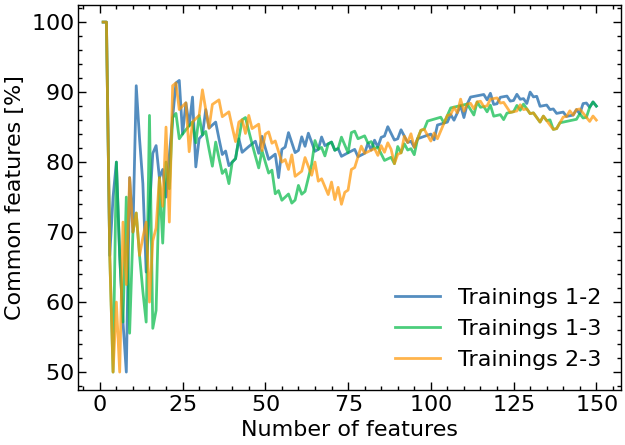

In [10]:
fig, ax = plt.subplots(1,figsize=(7,5))

intersections_12 = np.zeros(n_coords)
intersections_13 = np.zeros(n_coords)
intersections_23 = np.zeros(n_coords)
for i_feat in range(n_coords):
    intersection_train1_train2 = set(variables_train[0][i_feat]).intersection(variables_train[1][i_feat])
    intersection_train1_train3 = set(variables_train[0][i_feat]).intersection(variables_train[2][i_feat])
    intersection_train2_train3 = set(variables_train[1][i_feat]).intersection(variables_train[2][i_feat])
    intersections_12[i_feat] = len(intersection_train1_train2)
    intersections_13[i_feat] = len(intersection_train1_train3)
    intersections_23[i_feat] = len(intersection_train2_train3)
ax.plot(np.arange(1,n_coords+1), intersections_12 / np.arange(1,n_coords+1) * 100, '-', label=f"Trainings 1-2", alpha=0.7)
ax.plot(np.arange(1,n_coords+1), intersections_13 / np.arange(1,n_coords+1) * 100, '-', label=f"Trainings 1-3", alpha=0.7)
ax.plot(np.arange(1,n_coords+1), intersections_23 / np.arange(1,n_coords+1) * 100, '-', label=f"Trainings 2-3", alpha=0.7)
ax.set(xlabel="Number of features", ylabel="Common features [%]")
ax.legend()
plt.savefig("./figures/transferability_features.pdf", dpi=300)
plt.show()

### Matrix of pair-wise imbalances

In [21]:
features, matrix_imb = pickle.load(open("./pickles/matrix_imbalances_ncoords30_k30.p","rb"))
print(np.array(features).shape,np.array(matrix_imb).shape)

(25,) (25, 25)


[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.99187541 0.99255096 0.99282163 0.9930622  0.99306688
 0.99306922 0.99309591 0.99318354 0.99320736 0.99349574 0.99355901
 0.99356548 0.99356918 0.99386264 0.99389542 0.99391999 0.99394377
 0.99403511 0.99410182 0.99410491 0.99415867 0.99419815 0.99423448
 0.99427757 0.9943266  0.99433677 0.9943819  0.99440676 0.9944169
 0.99444245 0.99450121 0.99452882 0.99458043 0.99475893 0.99476465
 0.9947692  0.99477314 0.99480949 0.99480998 0.99481062 0.99483587
 0.99485248 0.99489019 0.99490486 0.99491531 0.99493592 0.99494683
 0.99496825 0.99498225 0.99499279 0.99501153 0.99504343 0.99504718
 0.99507579 0.99509521 0.99513031 0.99514163 0.99517035 0.99517417
 0.99519182 0.99524175 0.99524371 0.99525587 0.99529091 0.99532217
 0.99532304 0.99533027 0.995

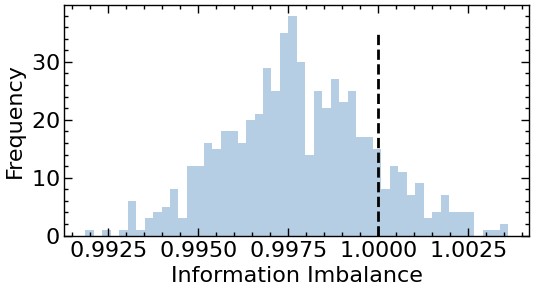

In [34]:
sorted_imbs = np.sort(np.array(matrix_imb).flatten())
print(sorted_imbs)

plt.figure(figsize=(6,3))
plt.hist(sorted_imbs[25:],bins=50,alpha=0.3)
plt.vlines(1,0,35,linestyle="--",color="black")
plt.xlabel("Information Imbalance")
plt.ylabel("Frequency")
plt.show()
